Mount Drive + imports

In [ ]:
import os, sys, json, math, random
import numpy as np
import pandas as pd
import cv2
import torch

from google.colab import drive

drive.mount('/content/drive', force_remount=True)

print("✅ Drive mounted.")


Mounted at /content/drive
✅ Drive mounted.


Paths (keep exactly as you described)

In [ ]:
PROJECT_ROOT = '/content/drive/MyDrive/final project'
DATA_ROOT    = os.path.join(PROJECT_ROOT, 'data-root')
OUTPUT_DIR   = os.path.join(PROJECT_ROOT, 'processed_tensors')

PATCHES_DIR  = os.path.join(OUTPUT_DIR, 'patches')
KPTS_DIR     = os.path.join(OUTPUT_DIR, 'kpts')

os.makedirs(PATCHES_DIR, exist_ok=True)
os.makedirs(KPTS_DIR, exist_ok=True)

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

print("✅ Paths ready:")
print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_ROOT   :", DATA_ROOT)
print("OUTPUT_DIR  :", OUTPUT_DIR)
print("PATCHES_DIR :", PATCHES_DIR)
print("KPTS_DIR    :", KPTS_DIR)


✅ Paths ready:
PROJECT_ROOT: /content/drive/MyDrive/final project
DATA_ROOT   : /content/drive/MyDrive/final project/data-root
OUTPUT_DIR  : /content/drive/MyDrive/final project/processed_tensors
PATCHES_DIR : /content/drive/MyDrive/final project/processed_tensors/patches
KPTS_DIR    : /content/drive/MyDrive/final project/processed_tensors/kpts


Load Label.xlsx and clean merged cells

In [ ]:
labels_xlsx = os.path.join(PROJECT_ROOT, 'Label.xlsx')
df = pd.read_excel(labels_xlsx)

# Handle merged PatID/Seizure Type cells
df[['PatID', 'Seizure Type']] = df[['PatID', 'Seizure Type']].ffill()

# Standardize
df['PatID'] = df['PatID'].astype(str).str.lower().str.strip()
df['Seizure Type'] = df['Seizure Type'].astype(str).str.strip()

print("✅ Excel loaded:", df.shape)
display(df.head())


✅ Excel loaded: (33, 5)


,PatID,Seizure Type,#Seizure,EEG onset,Clinical Onset
0,pat01,PG,Sz1,00:59:40,00:59:51
1,pat01,PG,Sz2,00:10:24,00:10:40
2,pat02,PG,Sz1,00:47:06,00:47:38
3,pat02,PG,Sz2,00:08:10,00:08:59
4,pat03,PG,Sz1,00:00:07,00:00:13


Load pose model (same as your project)

In [ ]:
from modules.load_state import load_state
from models.with_mobilenet import PoseEstimationWithMobileNet
from modules.keypoints import extract_keypoints, group_keypoints

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

net = PoseEstimationWithMobileNet().to(DEVICE).eval()
pose_path = os.path.join(PROJECT_ROOT, 'pose.pth')
load_state(net, torch.load(pose_path, map_location=DEVICE))

print("✅ Pose model loaded on:", DEVICE)


✅ Pose model loaded on: cuda


Paper settings (Gaussian + joint order)

In [ ]:
import numpy as np
import math

# VSViG Paper Settings [cite: 168, 290]
FINAL_PATCH_SIZE = 32
FUSION_SIZE = 128  # Use higher res for smoother fusion logic
SIGMA_SCALE = 0.3
SIGMA = FUSION_SIZE * SIGMA_SCALE # Sigma relative to fusion size [cite: 290]

# 1. Generate High-Res Gaussian Kernel (Matches 'other' code math)
# center at 63.5 for 128x128 grid
xs = np.arange(FUSION_SIZE, dtype=np.float32)
ys = np.arange(FUSION_SIZE, dtype=np.float32)
xx, yy = np.meshgrid(xs, ys, indexing='xy')

# Formula from VSViG Eq 1 [cite: 168]
gauss = np.exp(-((xx - 63.5)**2 + (yy - 63.5)**2) / (2 * (SIGMA**2)))

# 2. Normalize to [0,1] strictly
gauss = gauss / np.max(gauss)
g_filter_high = np.repeat(gauss[:, :, None], 3, axis=2).astype(np.float32)

# 3. Correct VSViG Joint Order (15 Joints)
# Corrected to match Source Code [6]
JOINT_INDICES = [
    0,         # Nose
    14, 15,    # Eyes (Head Partition)
    2, 3, 4,   # Right Arm Partition
    5, 6, 7,   # Left Arm Partition  <-- SWAPPED to match code
    8, 9, 10,  # Right Leg Partition <-- SWAPPED to match code
    11, 12, 13 # Left Leg Partition
]

print(f"✅ High-Res Gaussian ({FUSION_SIZE}x{FUSION_SIZE}) + JOINT_INDICES ready.")

✅ High-Res Gaussian (128x128) + JOINT_INDICES ready.


Time parsing + label function

In [ ]:
def get_sec(time_val):
    if pd.isna(time_val):
        return None
    # pandas time/datetime
    if hasattr(time_val, 'hour'):
        return int(time_val.hour) * 3600 + int(time_val.minute) * 60 + int(time_val.second)
    # string HH:MM:SS or MM:SS
    try:
        parts = str(time_val).split(':')
        if len(parts) == 3:
            h, m, s = map(int, parts)
            return h * 3600 + m * 60 + s
        if len(parts) == 2:
            m, s = map(int, parts)
            return m * 60 + s
    except:
        return None
    return None

def calculate_label_formal(current_time, eeg_start, clinical_start, k=5):
    """
    Formal VSViG Exponential labeling[cite: 263, 562].
    k=5 is a standard growth factor for seizure likelihood.
    """
    if current_time < eeg_start:
        return 0.0 # Interictal [cite: 263]

    if current_time > clinical_start:
        return 1.0 # Ictal [cite: 263]

    # Transition period exponential growth [cite: 263, 280]
    transition_len = clinical_start - eeg_start
    if transition_len <= 0: return 1.0

    x = (current_time - eeg_start) / transition_len
    label = (np.exp(k * x) - 1) / (np.exp(k) - 1) #
    return float(label)


Pose extraction (same logic, but safe + consistent)

In [ ]:
def process_maps_to_coords(heatmap, paf, scale, orig_h, orig_w, prev_kpts=None):
    """
    1. Tries PAF Grouping (Best).
    2. Fallback: ROI Search around previous frame (Spatial Consistency).
    3. Last Resort: Global Maxima (only if no history).
    """

    # 1. Run Standard Extraction
    all_kpts, total = [], 0
    for i in range(18):
        total += extract_keypoints(heatmap[i], all_kpts, total)

    coords = np.full((18, 3), -1.0, dtype=np.float32)

    # --- STRATEGY A: PAF Grouping (The Gold Standard) ---
    paf_hwc = paf.transpose(1, 2, 0)
    poses, all_res = group_keypoints(all_kpts, paf_hwc)

    if poses is not None and len(poses) > 0:
        # If we have history, pick the pose closest to the previous skeleton
        if prev_kpts is not None:
             # Calculate distance between each candidate pose and the previous skeleton
             best_pose_idx = -1
             min_dist = float('inf')

             for p_idx, pose_candidate in enumerate(poses):
                 # Compare only valid joints
                 dist = 0
                 valid_joints = 0
                 for i in range(18):
                     if pose_candidate[i] != -1 and prev_kpts[i][2] > 0:
                         kpt_cand = all_res[int(pose_candidate[i])]
                         # Convert to real scale for comparison
                         x_cand = kpt_cand[0] * 8.0 / scale
                         y_cand = kpt_cand[1] * 8.0 / scale

                         dist += np.sqrt((x_cand - prev_kpts[i][0])**2 + (y_cand - prev_kpts[i][1])**2)
                         valid_joints += 1

                 if valid_joints > 0:
                     avg_dist = dist / valid_joints
                     if avg_dist < min_dist:
                         min_dist = avg_dist
                         best_pose_idx = p_idx

             # Use the closest pose if we found a match, otherwise fallback to "most parts"
             if best_pose_idx != -1:
                 pose = poses[best_pose_idx]
             else:
                 pose = poses[max(range(len(poses)), key=lambda p: int(np.sum(poses[p][:18] != -1)))]
        else:
            # No history? Pick the one with most parts
            pose = poses[max(range(len(poses)), key=lambda p: int(np.sum(poses[p][:18] != -1)))]

        # Fill coords
        for i in range(18):
            if pose[i] != -1:
                kpt = all_res[int(pose[i])]
                coords[i] = [kpt[0] * 8.0 / scale, kpt[1] * 8.0 / scale, kpt[2]]

        return coords

    # --- STRATEGY B: ROI Search (Spatial Consistency) ---
    # Only runs if PAF failed.
    # We look for the max ONLY near the previous joint location.

    heatmap_h, heatmap_w = heatmap[0].shape
    search_radius = int(50 * scale / 8.0) # e.g., 50px radius scaled down to heatmap size
    if search_radius < 3: search_radius = 3

    for i in range(18):
        # Do we have a valid previous location for this joint?
        if prev_kpts is not None and prev_kpts[i][2] > 0.1:
            # Convert real coords back to heatmap coords
            prev_x_hm = int(prev_kpts[i][0] * scale / 8.0)
            prev_y_hm = int(prev_kpts[i][1] * scale / 8.0)

            # Define ROI (Window)
            x_min = max(0, prev_x_hm - search_radius)
            x_max = min(heatmap_w, prev_x_hm + search_radius)
            y_min = max(0, prev_y_hm - search_radius)
            y_max = min(heatmap_h, prev_y_hm + search_radius)

            # Crop heatmap to ROI
            roi = heatmap[i][y_min:y_max, x_min:x_max]

            if roi.size > 0:
                min_val, conf, min_loc, max_loc = cv2.minMaxLoc(roi)

                # If confident enough inside the window
                if conf > 0.05:
                    # Adjust local ROI coords back to global heatmap coords
                    global_x = x_min + max_loc[0]
                    global_y = y_min + max_loc[1]

                    coords[i] = [global_x * 8.0 / scale, global_y * 8.0 / scale, conf]
                    continue # Success! Move to next joint.

        # --- STRATEGY C: Global Search (Last Resort) ---
        # Only if we had no history OR the ROI search found nothing
        min_val, conf, min_loc, max_loc = cv2.minMaxLoc(heatmap[i])
        if conf > 0.1: # Higher threshold for global search to avoid noise
            coords[i] = [max_loc[0] * 8.0 / scale, max_loc[1] * 8.0 / scale, conf]

    return coords

Core preprocessing: exact 5s window + 30 frames (FPS-robust)

In [ ]:
def extract_clip_tensors_batched(cap, fps, t_start_sec):
    """
    Extracts a 30-frame clip with IMPROVED Persistent History Imputation:
    - temporal carry-forward
    - velocity prediction
    - max missing frame reset
    - jump-distance rejection
    """

    # -------------------------
    # PARAMETERS (tune if needed)
    # -------------------------
    CONF_TH = 0.05
    MAX_MISSING = 5          # frames before we drop a joint
    DECAY_COPY = 0.95
    DECAY_PRED = 0.90
    MAX_JUMP = 80            # pixels — reject sudden jumps

    start_frame = int(round(t_start_sec * fps))
    end_frame   = int(round((t_start_sec + 5.0) * fps))

    # -------------------------
    # 1. Read Frames
    # -------------------------
    frame_idxs = np.linspace(start_frame, end_frame - 1, 30).astype(int)
    frames = []

    cap.set(cv2.CAP_PROP_POS_FRAMES, start_frame)
    current_read_idx = start_frame

    for _ in range(end_frame - start_frame):
        ret, frame = cap.read()
        if not ret:
            break

        if current_read_idx in frame_idxs:
            frames.append(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))

        current_read_idx += 1
        if len(frames) == 30:
            break

    if len(frames) < 30:
        return None, None

    # -------------------------
    # 2. Batch Pose Inference
    # -------------------------
    h, w, _ = frames[0].shape
    scale = 256.0 / float(h)

    batch_inp = [cv2.resize(f, (0, 0), fx=scale, fy=scale) for f in frames]
    batch_inp = np.stack(batch_inp).astype(np.float32)
    batch_inp = (batch_inp - 128.0) / 256.0

    batch_tensor = torch.from_numpy(batch_inp).permute(0, 3, 1, 2).to(DEVICE)

    with torch.no_grad():
        out = net(batch_tensor)
        all_heatmaps = out[-2].cpu().numpy()
        all_pafs = out[-1].cpu().numpy()

    # -------------------------
    # 3. Persistent Skeleton State
    # -------------------------
    pad = 64
    clip_patches, clip_kpts = [], []

    persistent = np.full((18, 3), -1.0, dtype=np.float32)
    prev_positions = np.full((18, 2), -1.0, dtype=np.float32)
    missing_count = np.zeros(18, dtype=np.int32)

    # -------------------------
    # 4. Frame Loop
    # -------------------------
    for i in range(30):

        raw_18_kpts = process_maps_to_coords(
            all_heatmaps[i],
            all_pafs[i],
            scale, h, w,
            prev_kpts=persistent
        )

        # -------- joint-wise repair --------
        for k in range(18):
            x, y, conf = raw_18_kpts[k]
            px, py, pconf = persistent[k]

            # -------------------------
            # CASE 1 — Good detection
            # -------------------------
            if conf > CONF_TH:

                # distance sanity check
                if pconf > CONF_TH:
                    dist = np.hypot(x - px, y - py)
                    if dist > MAX_JUMP:
                        # reject jump → treat as missing
                        conf = -1

                if conf > CONF_TH:
                    prev_positions[k] = persistent[k][:2]
                    persistent[k] = raw_18_kpts[k]
                    missing_count[k] = 0
                    continue

            # -------------------------
            # CASE 2 — Missing detection
            # -------------------------
            missing_count[k] += 1

            if pconf > CONF_TH and missing_count[k] <= MAX_MISSING:

                # try velocity prediction
                vx = px - prev_positions[k][0] if prev_positions[k][0] >= 0 else 0
                vy = py - prev_positions[k][1] if prev_positions[k][1] >= 0 else 0

                pred_x = px + vx
                pred_y = py + vy

                raw_18_kpts[k] = np.array([
                    pred_x,
                    pred_y,
                    pconf * DECAY_PRED
                ], dtype=np.float32)

                persistent[k] = raw_18_kpts[k]

            elif pconf > CONF_TH and missing_count[k] <= MAX_MISSING:
                # fallback to copy if no velocity history
                raw_18_kpts[k] = persistent[k].copy()
                raw_18_kpts[k][2] *= DECAY_COPY

            else:
                # too long missing → reset
                persistent[k] = np.array([-1, -1, -1], dtype=np.float32)

        # -------------------------
        # VSViG joint subset
        # -------------------------
        vsvig_coords = raw_18_kpts[JOINT_INDICES]
        clip_kpts.append(vsvig_coords)

        # -------------------------
        # Patch extraction
        # -------------------------
        p_img = cv2.copyMakeBorder(
            frames[i], pad, pad, pad, pad,
            cv2.BORDER_CONSTANT, value=0
        )

        p_batch = np.zeros((15, 32, 32, 3), dtype=np.float32)

        for j, (x, y, conf) in enumerate(vsvig_coords):
            if x < 0 or y < 0:
                continue

            x_p, y_p = int(round(x + pad)), int(round(y + pad))
            crop = p_img[y_p-64:y_p+64, x_p-64:x_p+64].astype(np.float32)

            if crop.shape == (128, 128, 3):
                fused = crop * g_filter_high
                p_batch[j] = cv2.resize(
                    fused, (32, 32),
                    interpolation=cv2.INTER_CUBIC
                ) / 255.0

        clip_patches.append(p_batch)

    patches = np.array(clip_patches).transpose(0, 1, 4, 2, 3)
    return patches, np.array(clip_kpts)

Process one video (windowed 30min before EEG to 2min after clinical)

In [ ]:
def process_video_to_vsvig(v_path, pat_id, sz_id, eeg_s, clin_s, window_start, window_end):
    cap = cv2.VideoCapture(v_path)
    if not cap.isOpened():
        print(f"❌ Skipping (cannot open): {v_path}")
        return 0

    fps = cap.get(cv2.CAP_PROP_FPS)
    if not fps or fps <= 0:
        print(f"❌ Bad FPS for: {v_path}")
        cap.release()
        return 0

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    duration_sec = total_frames / fps

    t = max(float(window_start), 0.0)
    effective_end = min(float(window_end), duration_sec - 5.0)

    count = 0
    fail = 0

    print(f"🎬 {pat_id} | Sz={sz_id} | fps={fps:.2f} | window=[{t:.1f},{effective_end:.1f}]")

    while t <= effective_end:
        # 1. Stride Policy: 5s for distant interictal, 1s for critical periods
        is_crit = (t + 5.0) > eeg_s
        stride = 1.0 if is_crit else 5.0

        # 2. Formal Exponential Labeling
        # The probability depends on the end frame of the 5s clip
        label = calculate_label_formal(t + 5.0, eeg_s, clin_s)

        # 3. High-Fidelity Batched Extraction (128x128 -> 32x32)
        patches, kpts = extract_clip_tensors_batched(cap, fps, t)

        if patches is None:
            fail += 1
            t += stride
            continue

        # 4. Save Tensors for Training
        t_int = int(round(t))
        file_id = f"{pat_id}_{sz_id}_{t_int}"

        # Patches shape: (T=30, N=15, C=3, H=32, W=32) [cite: 584]
        patch_tensor = torch.from_numpy(patches).float()
        # Keypoints shape: (T=30, N=15, 3)
        kpts_tensor  = torch.from_numpy(kpts).float()

        torch.save(patch_tensor, os.path.join(PATCHES_DIR, f"{file_id}.pt"))
        torch.save(kpts_tensor,  os.path.join(KPTS_DIR,    f"{file_id}.pt"))

        # 5. Master Label Entry
        master_labels[file_id] = float(label)

        count += 1
        if count % 20 == 0:
            print(f"  📦 Saved {file_id} | stride={stride:.0f}s | label={label:.3f} | fails={fail}")

        t += stride

    cap.release()
    print(f"✅ Done: {pat_id} Sz={sz_id} | clips={count} | fails={fail}")
    return count

Run preprocessing for all rows in Label.xlsx

In [ ]:
master_labels = {}
total_clips = 0
missing_videos = 0
skipped_rows = 0

for _, row in df.iterrows():
    p_id = str(row['PatID']).strip().lower()     # match folder naming
    sz_id = str(row['#Seizure']).strip()         # keep "Sz1" as-is
    sz_type = str(row['Seizure Type']).strip()

    eeg_s  = get_sec(row.get('EEG onset', None))
    clin_s = get_sec(row.get('Clinical Onset', None))

    if eeg_s is None or clin_s is None or clin_s <= eeg_s:
        skipped_rows += 1
        print(f"⚠️ Skip row: {p_id} seizure={sz_id} invalid times (EEG={eeg_s}, Clin={clin_s})")
        continue

    # Paper windowing
    start_time = max(0.0, float(eeg_s) - 1800.0)
    end_time   = float(clin_s) + 120.0

    v_name = f"{sz_id}{sz_type}.mp4"
    v_path = os.path.join(DATA_ROOT, p_id, v_name)

    if not os.path.exists(v_path):
        missing_videos += 1
        print(f"❌ Video not found: {v_path}")
        continue

    total_clips += process_video_to_vsvig(
        v_path=v_path,
        pat_id=p_id,
        sz_id=sz_id,           # keep "Sz1" in file_id too
        eeg_s=eeg_s,
        clin_s=clin_s,
        window_start=start_time,
        window_end=end_time
    )

print("\n🏁 Preprocessing complete.")
print("Total clips:", total_clips)
print("Total label entries:", len(master_labels))
print("Missing videos:", missing_videos)
print("Skipped rows (bad onset times):", skipped_rows)


🎬 pat01 | Sz=Sz1 | fps=29.97 | window=[1780.0,3649.3]
  📦 Saved pat01_Sz1_1875 | stride=5s | label=0.000 | fails=0
  📦 Saved pat01_Sz1_1975 | stride=5s | label=0.000 | fails=0
  📦 Saved pat01_Sz1_2075 | stride=5s | label=0.000 | fails=0
  📦 Saved pat01_Sz1_2175 | stride=5s | label=0.000 | fails=0
  📦 Saved pat01_Sz1_2275 | stride=5s | label=0.000 | fails=0
  📦 Saved pat01_Sz1_2375 | stride=5s | label=0.000 | fails=0
  📦 Saved pat01_Sz1_2475 | stride=5s | label=0.000 | fails=0
  📦 Saved pat01_Sz1_2575 | stride=5s | label=0.000 | fails=0
  📦 Saved pat01_Sz1_2675 | stride=5s | label=0.000 | fails=0
  📦 Saved pat01_Sz1_2775 | stride=5s | label=0.000 | fails=0
  📦 Saved pat01_Sz1_2875 | stride=5s | label=0.000 | fails=0
  📦 Saved pat01_Sz1_2975 | stride=5s | label=0.000 | fails=0
  📦 Saved pat01_Sz1_3075 | stride=5s | label=0.000 | fails=0
  📦 Saved pat01_Sz1_3175 | stride=5s | label=0.000 | fails=0
  📦 Saved pat01_Sz1_3275 | stride=5s | label=0.000 | fails=0
  📦 Saved pat01_Sz1_3375 | stri

In [ ]:
labels_path = os.path.join(OUTPUT_DIR, 'labels.json')
with open(labels_path, 'w') as f:
    json.dump(master_labels, f)

print("✅ Saved:", labels_path)


✅ Saved: /content/drive/MyDrive/final project/processed_tensors/labels.json


In [ ]:
labels_path = os.path.join(OUTPUT_DIR, "labels.json")  # adjust if needed
with open(labels_path, "r") as f:
    labels = json.load(f)

In [ ]:
import os, glob, json, torch
import numpy as np



patch_files = sorted(glob.glob(os.path.join(PATCHES_DIR, "*.pt")))
kpt_files   = sorted(glob.glob(os.path.join(KPTS_DIR, "*.pt")))

print("labels entries:", len(labels))
print("patch files:", len(patch_files))
print("kpt files:", len(kpt_files))

# Check alignment for a sample of IDs
sample_ids = list(labels.keys())[:50]
missing = 0
bad_shapes = 0

for fid in sample_ids:
    p_path = os.path.join(PATCHES_DIR, f"{fid}.pt")
    k_path = os.path.join(KPTS_DIR, f"{fid}.pt")
    if not (os.path.exists(p_path) and os.path.exists(k_path)):
        missing += 1
        continue
    p = torch.load(p_path, map_location="cpu")
    k = torch.load(k_path, map_location="cpu")
    if tuple(p.shape) != (30,15,3,32,32) or tuple(k.shape) != (30,15,2):
        bad_shapes += 1

print("missing sample files:", missing)
print("bad shape sample files:", bad_shapes)


labels entries: 4853
patch files: 4853
kpt files: 4853
missing sample files: 0
bad shape sample files: 50


In [ ]:
import re
from collections import defaultdict, Counter

def parse_fid(fid):
    # expects: pat01_Sz1_1875
    parts = fid.split("_")
    if len(parts) < 3:
        return None
    pat = parts[0]
    sz  = parts[1]
    try:
        t = int(parts[2])
    except:
        return None
    return pat, sz, t

by_event = defaultdict(list)
for fid in labels.keys():
    parsed = parse_fid(fid)
    if parsed is None:
        continue
    pat, sz, t = parsed
    by_event[(pat, sz)].append(t)

# pick one event
event = sorted(by_event.keys())[0]
times = sorted(by_event[event])
diffs = [times[i+1]-times[i] for i in range(len(times)-1)]
cnt = Counter(diffs)

print("Event:", event)
print("Most common strides:", cnt.most_common(10))
print("min stride:", min(diffs), "max stride:", max(diffs), "num clips:", len(times))


Event: ('pat01', 'Sz1')
Most common strides: [(5, 360), (1, 69)]
min stride: 1 max stride: 5 num clips: 430


In [ ]:
vals = np.array(list(labels.values()), dtype=np.float32)

print("Label stats:")
print("  min:", float(vals.min()))
print("  max:", float(vals.max()))
print("  mean:", float(vals.mean()))

# how many are ~0 and ~1
z = np.mean(vals <= 1e-6)
o = np.mean(vals >= 1.0 - 1e-6)
mid = 1.0 - z - o

print("Fraction ~0:", float(z))
print("Fraction ~1:", float(o))
print("Fraction in (0,1):", float(mid))

# show a few mid-label examples
mid_ids = [fid for fid,v in labels.items() if 0.05 < float(v) < 0.95]
print("mid-label sample count:", len(mid_ids))
print("first 10 mid-label ids:", mid_ids[:10])


Label stats:
  min: 0.0
  max: 1.0
  mean: 0.6028434038162231
Fraction ~0: 0.3352565423449413
Fraction ~1: 0.5868534926849371
Fraction in (0,1): 0.07788996497012157
mid-label sample count: 256
first 10 mid-label ids: ['pat01_Sz1_3580', 'pat01_Sz1_3581', 'pat01_Sz1_3582', 'pat01_Sz1_3583', 'pat01_Sz1_3584', 'pat01_Sz1_3585', 'pat01_Sz2_626', 'pat01_Sz2_627', 'pat01_Sz2_628', 'pat01_Sz2_629']


In [ ]:
import random, torch

def kpt_missing_rate(kpts):
    # kpts: (30,15,2)
    x = kpts[...,0]
    y = kpts[...,1]
    missing = (x < 0) | (y < 0)
    return float(missing.mean())

random_ids = random.sample(list(labels.keys()), k=min(30, len(labels)))
rates = []

for fid in random_ids:
    k_path = os.path.join(KPTS_DIR, f"{fid}.pt")
    k = torch.load(k_path, map_location="cpu").numpy()
    rates.append(kpt_missing_rate(k))

print("Missing rate across 30 samples:")
print("  mean:", float(np.mean(rates)))
print("  median:", float(np.median(rates)))
print("  max:", float(np.max(rates)))


Missing rate across 30 samples:
  mean: 0.07044444444444445
  median: 0.05
  max: 0.38222222222222224


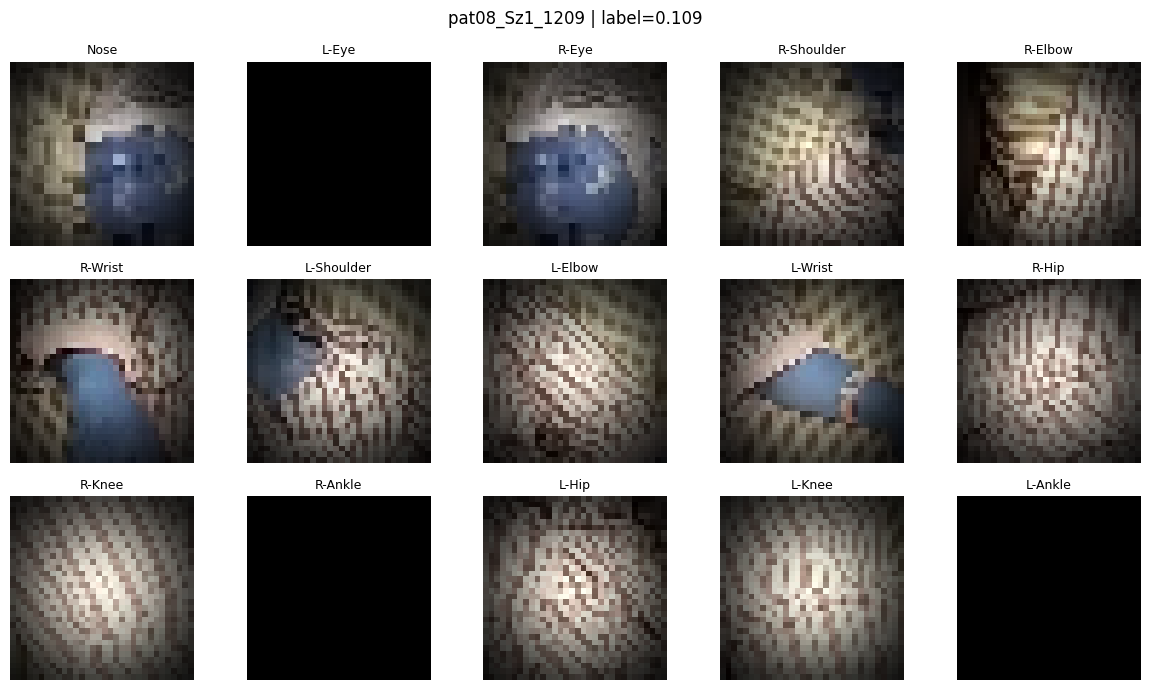

In [ ]:
import matplotlib.pyplot as plt
import torch, numpy as np, random, os

JOINT_NAMES = [
    "Nose","L-Eye","R-Eye",
    "R-Shoulder","R-Elbow","R-Wrist",
    "L-Shoulder","L-Elbow","L-Wrist",
    "R-Hip","R-Knee","R-Ankle",
    "L-Hip","L-Knee","L-Ankle"
]

fid = random.choice(list(labels.keys()))
p = torch.load(os.path.join(PATCHES_DIR, f"{fid}.pt"), map_location="cpu").numpy()  # (30,15,3,32,32)

t_idx = 0  # first frame in the clip
fig, axes = plt.subplots(3, 5, figsize=(12, 7))
axes = axes.ravel()

for j in range(15):
    patch = p[t_idx, j].transpose(1,2,0)  # (32,32,3)
    patch = np.clip(patch, 0, 1)
    axes[j].imshow(patch[..., ::-1])  # BGR->RGB if needed; remove if already RGB
    axes[j].set_title(JOINT_NAMES[j], fontsize=9)
    axes[j].axis("off")

plt.suptitle(f"{fid} | label={labels[fid]:.3f}", fontsize=12)
plt.tight_layout()
plt.show()


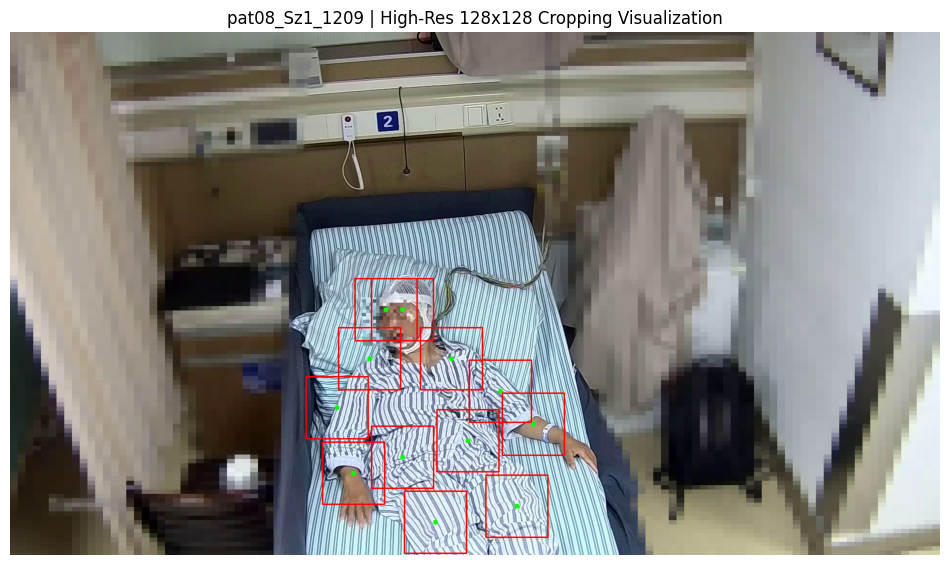

In [ ]:
# ---- parse identifiers ----
parts = fid.split("_")
pat_id = parts[0]
sz_id  = parts[1]
t_sec  = int(parts[2])

# ---- reconstruct video path ----
row = df[(df['PatID'].str.lower() == pat_id) & (df['#Seizure'].astype(str) == sz_id)].iloc[0]
sz_type = str(row['Seizure Type']).strip()
video_path = os.path.join(DATA_ROOT, pat_id, f"{sz_id}{sz_type}.mp4")

# ---- grab frame ----
cap = cv2.VideoCapture(video_path)
fps = cap.get(cv2.CAP_PROP_FPS)
cap.set(cv2.CAP_PROP_POS_FRAMES, int(t_sec * fps))
ret, bgr_frame = cap.read() # Read in BGR [cite: 114, 213]
cap.release()
assert ret, "Could not read frame"

# Convert to RGB to match your new extract_clip_tensors_batched logic
frame = cv2.cvtColor(bgr_frame, cv2.COLOR_BGR2RGB) #

# ---- NEW LOGIC: Prepare inputs for the helper function ----
orig_h, orig_w = frame.shape[:2]
scale = 256.0 / float(orig_h) # Match your preprocessing height [cite: 582, 584]

# 1. Preprocess and run inference
inp = cv2.resize(frame, (0, 0), fx=scale, fy=scale)
inp = (inp.astype(np.float32) - 128.0) / 256.0 # Correct normalization
tensor = torch.from_numpy(inp).permute(2, 0, 1).unsqueeze(0).to(DEVICE)

with torch.no_grad():
    out = net(tensor)
    # Heatmaps are index -2, PAFs are index -1 [cite: 210, 246]
    heatmap = out[-2].squeeze().cpu().numpy()
    paf     = out[-1].squeeze().cpu().numpy()

# 2. Call the helper with all required arguments
raw_kpts = process_maps_to_coords(heatmap, paf, scale, orig_h, orig_w)
vsvig_kpts = raw_kpts[JOINT_INDICES]

# ---- draw and show ----
vis = frame.copy()
# IMPORTANT: Update pad to 64 to visualize the 128x128 crop area
visual_pad = 64

for j, (x, y, _) in enumerate(vsvig_kpts):
    if x < 0 or y < 0: continue
    x_vis, y_vis = int(round(x)), int(round(y))

    # draw joint (green dot)
    cv2.circle(vis, (x_vis, y_vis), 5, (0, 255, 0), -1)

    # draw crop box (red rectangle) representing the 128x128 area
    cv2.rectangle(
        vis,
        (x_vis - visual_pad, y_vis - visual_pad),
        (x_vis + visual_pad, y_vis + visual_pad),
        (255, 0, 0),
        2
    )

plt.figure(figsize=(12, 8))
plt.imshow(vis) # Already RGB
plt.title(f"{fid} | High-Res 128x128 Cropping Visualization")
plt.axis("off")
plt.show()

In [ ]:
import numpy as np, torch, os, random

fid = random.choice(list(labels.keys()))
p = torch.load(os.path.join(PATCHES_DIR, f"{fid}.pt"), map_location="cpu").numpy()  # (30,15,3,32,32)

# pick one joint and one frame
t_idx, j = 10, 0
patch = p[t_idx, j].mean(axis=0)  # (32,32) grayscale

center = patch[14:18,14:18].mean()
edges  = np.concatenate([
    patch[0,:], patch[-1,:], patch[:,0], patch[:,-1]
]).mean()

print("center mean:", float(center))
print("edges mean:", float(edges))
print("center/edges ratio:", float(center/(edges+1e-8)))


center mean: 0.3808597922325134
edges mean: 0.08661067485809326
center/edges ratio: 4.397376537322998


In [ ]:
from collections import defaultdict
import numpy as np

# choose an event with many clips
event = sorted(by_event.keys(), key=lambda k: -len(by_event[k]))[0]
times = sorted(by_event[event])

labels_by_t = [(t, labels[f"{event[0]}_{event[1]}_{t}"]) for t in times if f"{event[0]}_{event[1]}_{t}" in labels]
labels_by_t = labels_by_t[:300]  # limit print

print("Event:", event, "num clips:", len(labels_by_t))
print("First 20:", labels_by_t[:20])
print("Last 20:", labels_by_t[-20:])

# show where label first becomes >0
for t,v in labels_by_t:
    if v > 0.0:
        print("First non-zero label at t=", t, "label=", v)
        break


Event: ('pat02', 'Sz1') num clips: 300
First 20: [(1026, 0.0), (1031, 0.0), (1036, 0.0), (1041, 0.0), (1046, 0.0), (1051, 0.0), (1056, 0.0), (1061, 0.0), (1066, 0.0), (1071, 0.0), (1076, 0.0), (1081, 0.0), (1086, 0.0), (1091, 0.0), (1096, 0.0), (1101, 0.0), (1106, 0.0), (1111, 0.0), (1116, 0.0), (1121, 0.0)]
Last 20: [(2426, 0.0), (2431, 0.0), (2436, 0.0), (2441, 0.0), (2446, 0.0), (2451, 0.0), (2456, 0.0), (2461, 0.0), (2466, 0.0), (2471, 0.0), (2476, 0.0), (2481, 0.0), (2486, 0.0), (2491, 0.0), (2496, 0.0), (2501, 0.0), (2506, 0.0), (2511, 0.0), (2516, 0.0), (2521, 0.0)]


split data

In [ ]:
import json
import random
import os
from collections import defaultdict

def split_and_export_vsvig_formal(master_labels, output_dir):
    """
    Formal VSViG splitting logic:
    - 5-second duration logic for all reporting.
    - Added Validation hour stats.
    """
    seizure_map = defaultdict(lambda: {'transition': [], 'ictal': []})
    inter_pool = []

    for fid, lbl in master_labels.items():
        sz_id = "_".join(fid.split("_")[:2])
        if lbl == 0.0:
            inter_pool.append(fid)
        elif 0.0 < lbl < 1.0:
            seizure_map[sz_id]['transition'].append(fid)
        else:
            seizure_map[sz_id]['ictal'].append(fid)

    # Split 20% from EACH Seizure individually
    val_unhealthy, train_unhealthy = [], []
    random.seed(42)

    for sz_id, data in seizure_map.items():
        trans_clips, ictal_clips = data['transition'], data['ictal']
        random.shuffle(trans_clips)
        random.shuffle(ictal_clips)

        n_val_trans, n_val_ictal = int(len(trans_clips) * 0.20), int(len(ictal_clips) * 0.20)

        val_unhealthy.extend(trans_clips[:n_val_trans])
        train_unhealthy.extend(trans_clips[n_val_trans:])
        val_unhealthy.extend(ictal_clips[:n_val_ictal])
        train_unhealthy.extend(ictal_clips[n_val_ictal:])

    # Balance Healthy 1:1 for Validation
    target_val_count = len(val_unhealthy)
    random.shuffle(inter_pool)
    val_healthy = inter_pool[:target_val_count]
    train_healthy = inter_pool[target_val_count:]

    train_fids = train_unhealthy + train_healthy
    val_fids = val_unhealthy + val_healthy

    # Export to JSON
    with open(os.path.join(output_dir, 'train_fids.json'), 'w') as f:
        json.dump(train_fids, f)
    with open(os.path.join(output_dir, 'val_fids.json'), 'w') as f:
        json.dump(val_fids, f)

    # ---- REPORTING (Using 5-second Volume Logic) ----
    def to_hrs(count): return (count * 5.0) / 3600.0

    # Training Counts
    t_trans = [f for f in train_unhealthy if 0 < master_labels[f] < 1]
    t_ictal = [f for f in train_unhealthy if master_labels[f] >= 1]

    # Validation Counts
    v_trans = [f for f in val_unhealthy if 0 < master_labels[f] < 1]
    v_ictal = [f for f in val_unhealthy if master_labels[f] >= 1]

    print("-" * 55)
    print(f"{'CATEGORY':<20} | {'CLIPS':<8} | {'VOLUME (HRS)':<12}")
    print("-" * 55)
    print(f"Interictal (Train):  {len(train_healthy):<8} | {to_hrs(len(train_healthy)):.4f} hrs")
    print(f"Transition (Train):  {len(t_trans):<8} | {to_hrs(len(t_trans)):.4f} hrs")
    print(f"Ictal (Train):       {len(t_ictal):<8} | {to_hrs(len(t_ictal)):.4f} hrs")
    print("-" * 55)
    print(f"Interictal (Val):    {len(val_healthy):<8} | {to_hrs(len(val_healthy)):.4f} hrs")
    print(f"Transition (Val):    {len(v_trans):<8} | {to_hrs(len(v_trans)):.4f} hrs")
    print(f"Ictal (Val):         {len(v_ictal):<8} | {to_hrs(len(v_ictal)):.4f} hrs")
    print("-" * 55)
    print(f"✅ Training Set:    {len(train_fids):<8} | {to_hrs(len(train_fids)):.4f} hrs")
    print(f"✅ Validation Set:  {len(val_fids):<8} | {to_hrs(len(val_fids)):.4f} hrs")
    print("-" * 55)

    return train_fids, val_fids

# Execute the split
train_fids, val_fids = split_and_export_vsvig_formal(labels, OUTPUT_DIR)

-------------------------------------------------------
CATEGORY             | CLIPS    | VOLUME (HRS)
-------------------------------------------------------
Interictal (Train):  1004     | 1.3944 hrs
Transition (Train):  312      | 0.4333 hrs
Ictal (Train):       2291     | 3.1819 hrs
-------------------------------------------------------
Interictal (Val):    623      | 0.8653 hrs
Transition (Val):    66       | 0.0917 hrs
Ictal (Val):         557      | 0.7736 hrs
-------------------------------------------------------
✅ Training Set:    3607     | 5.0097 hrs
✅ Validation Set:  1246     | 1.7306 hrs
-------------------------------------------------------
